In [1]:
import qutip as qt
from qutip import tensor, basis
import numpy as np
import matplotlib.pyplot as plt
from quantum_logical.channel import AmplitudeDamping, PhaseDamping
from quantum_logical.trotter import TrotterGroup
from tqdm import tqdm
from scipy.optimize import curve_fit
from itertools import product
from quantum_logical.trotterization import Trotterization

In [2]:
# generating parameters and creating initial state
T1 = 1
T2 = .5

N = 5
dim = 2
trotter_dt = .001

# initializing Trotterization
trotter = Trotterization(trotter_dt=trotter_dt, T1=T1, T2=T2, dim=dim, num_qubits=N)

In [3]:
# %%capture
# build cnot comparitors 
cnot1 = qt.cnot(N=5, control=0, target=1)
cnot2 = qt.cnot(N=5, control=0, target=2)

cnot3 = qt.cnot(N=5, control=0, target=3)
cnot4 = qt.cnot(N=5, control=1, target=3)

cnot5 = qt.cnot(N=5, control=1, target=4)
cnot6 = qt.cnot(N=5, control=2, target=4)

x_gate = qt.Qobj([[0, 1],[1, 0]])

/var/folders/nc/8sqqbv456mdfx096ks86vy8m0000gn/T/ipykernel_80743/1342362625.py:3: DeprecationWarning: Importing functions/classes of the qip submodule directly from the namespace qutip is deprecated. Please import them from the submodule instead, e.g.
from qutip.qip.operations import cnot
from qutip.qip.circuit import QubitCircuit

  cnot1 = qt.cnot(N=5, control=0, target=1)
/var/folders/nc/8sqqbv456mdfx096ks86vy8m0000gn/T/ipykernel_80743/1342362625.py:4: DeprecationWarning: Importing functions/classes of the qip submodule directly from the namespace qutip is deprecated. Please import them from the submodule instead, e.g.
from qutip.qip.operations import cnot
from qutip.qip.circuit import QubitCircuit

  cnot2 = qt.cnot(N=5, control=0, target=2)
/var/folders/nc/8sqqbv456mdfx096ks86vy8m0000gn/T/ipykernel_80743/1342362625.py:6: DeprecationWarning: Importing functions/classes of the qip submodule directly from the namespace qutip is deprecated. Please import them from the submodule instea

In [4]:
# state controls 
alpha = 0
beta = 1

# state
psi0 = tensor((alpha * basis(dim, 0) + beta * basis(dim, 1)).unit(), tensor([basis(dim, 0)] * (N-1)))
rho0 = psi0 * psi0.dag()
rho_encoded = cnot2 * cnot1 * rho0 * cnot1.dag() * cnot2.dag()
rho_encoded_traced = qt.ptrace(rho_encoded, [0,1,2]) 
rho_encoded_traced # density matrix print confirmation

Quantum object: dims = [[2, 2, 2], [2, 2, 2]], shape = (8, 8), type = oper, isherm = True
Qobj data =
[[0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1.]]

In [5]:
# build_cnots based on schematic choice 
choice = [0,1,1,2] 
def scheme_choice(choice):
    cnot3 = qt.cnot(N = 5, control=choice[0], target=3)
    cnot4 = qt.cnot(N = 5, control=choice[1], target=3)

    cnot5 = qt.cnot(N = 5, control=choice[2], target=4)
    cnot6 = qt.cnot(N = 5, control=choice[3], target=4)

    return [cnot3, cnot4, cnot5, cnot6], [choice, [3,3,4,4]]

cnot_list, control_qubits = scheme_choice(choice=choice)

/var/folders/nc/8sqqbv456mdfx096ks86vy8m0000gn/T/ipykernel_80743/2308873525.py:4: DeprecationWarning: Importing functions/classes of the qip submodule directly from the namespace qutip is deprecated. Please import them from the submodule instead, e.g.
from qutip.qip.operations import cnot
from qutip.qip.circuit import QubitCircuit

  cnot3 = qt.cnot(N = 5, control=choice[0], target=3)
/var/folders/nc/8sqqbv456mdfx096ks86vy8m0000gn/T/ipykernel_80743/2308873525.py:5: DeprecationWarning: Importing functions/classes of the qip submodule directly from the namespace qutip is deprecated. Please import them from the submodule instead, e.g.
from qutip.qip.operations import cnot
from qutip.qip.circuit import QubitCircuit

  cnot4 = qt.cnot(N = 5, control=choice[1], target=3)
/var/folders/nc/8sqqbv456mdfx096ks86vy8m0000gn/T/ipykernel_80743/2308873525.py:7: DeprecationWarning: Importing functions/classes of the qip submodule directly from the namespace qutip is deprecated. Please import them from 

In [6]:
# user makes the gates that they want and sends them in 
circuit_gate_list = [[cnot3], [cnot4], [cnot5], [cnot6]]
def verifying_cnot_decomp(circuit_gate_list, cnot_list):
    for i in range(int(len(circuit_gate_list) / 4)):
        gate = tensor([qt.qeye(dim)] * N)
        for j in range(len(circuit_gate_list[i])):
            gate = circuit_gate_list[i][j] * gate
        if not gate.isunitary:
            raise ValueError("Gate is not unitary")
        gate = gate / gate[0,0]
        if cnot_list[i] != gate:
            raise ValueError("Not a valid decomp")

In [7]:
# sqrtiSWAP_DECOMP
# build the decomp gate set

x_gate_pi = qt.rx(np.pi, N=None)
x_gate_decomp = qt.rx(np.pi / 2, N=None)

y_gate_positive = qt.ry(np.pi / 2, N=None)
y_gate_negative = qt.ry(-np.pi / 2, N=None)

z_gate_positive = qt.rz(np.pi / 2, N=None)
z_gate_negative = qt.rz(- np.pi / 2, N=None)
z_gate_pi = qt.rz(-np.pi, N=None)


/var/folders/nc/8sqqbv456mdfx096ks86vy8m0000gn/T/ipykernel_80743/4095586859.py:4: DeprecationWarning: Importing functions/classes of the qip submodule directly from the namespace qutip is deprecated. Please import them from the submodule instead, e.g.
from qutip.qip.operations import cnot
from qutip.qip.circuit import QubitCircuit

  x_gate_pi = qt.rx(np.pi, N=None)
/var/folders/nc/8sqqbv456mdfx096ks86vy8m0000gn/T/ipykernel_80743/4095586859.py:5: DeprecationWarning: Importing functions/classes of the qip submodule directly from the namespace qutip is deprecated. Please import them from the submodule instead, e.g.
from qutip.qip.operations import cnot
from qutip.qip.circuit import QubitCircuit

  x_gate_decomp = qt.rx(np.pi / 2, N=None)
/var/folders/nc/8sqqbv456mdfx096ks86vy8m0000gn/T/ipykernel_80743/4095586859.py:7: DeprecationWarning: Importing functions/classes of the qip submodule directly from the namespace qutip is deprecated. Please import them from the submodule instead, e.g.
fr

In [8]:
# building the decomposition of the CNOT into an sqrtiSWAP 
total_cnots = []
for i in range(len(control_qubits[0])):
    single_cnot = []
    cnot_layer = [qt.qeye(dim) for _ in range(N)]
# layer one
    cnot_layer[control_qubits[0][i]] = z_gate_negative * y_gate_positive
    cnot_layer[control_qubits[1][i]] = y_gate_negative * z_gate_positive
    cnot_layer = tensor(cnot_layer)
    single_cnot.append(cnot_layer)
# # layer 2 
    iswap = qt.sqrtiswap(N = N, targets=[control_qubits[0][i], control_qubits[1][i]])
    single_cnot.append(iswap)
# # layer 3 
    cnot_layer = [qt.qeye(dim) for _ in range(N)]
    cnot_layer[control_qubits[0][i]] = x_gate_pi
    cnot_layer[control_qubits[1][i]] = z_gate_pi
    cnot_layer = tensor(cnot_layer)
    single_cnot.append(cnot_layer)
# # layer 4
    single_cnot.append(iswap)
# # layer 5 
    cnot_layer = [qt.qeye(dim) for _ in range(N)]
    cnot_layer[control_qubits[0][i]] = x_gate_decomp
    cnot_layer[control_qubits[1][i]] = z_gate_positive
    cnot_layer = tensor(cnot_layer)
    single_cnot.append(cnot_layer)
    total_cnots.append(single_cnot)

/var/folders/nc/8sqqbv456mdfx096ks86vy8m0000gn/T/ipykernel_80743/4229140030.py:12: DeprecationWarning: Importing functions/classes of the qip submodule directly from the namespace qutip is deprecated. Please import them from the submodule instead, e.g.
from qutip.qip.operations import cnot
from qutip.qip.circuit import QubitCircuit

  iswap = qt.sqrtiswap(N = N, targets=[control_qubits[0][i], control_qubits[1][i]])


In [9]:
# checking to see if this makes sense for a cnot 
verifying_cnot_decomp(circuit_gate_list=total_cnots, cnot_list=cnot_list)

In [10]:
time_list_each_layer = [.05, .05, .025, .05, .025]
# making sure that all of the cnots have the same layer count 
all(len(total_cnots[i]) == len(time_list_each_layer) for i in range(len(total_cnots)))

True

In [11]:
# build the circuit based on the information given 
# you have a gate list and the durations for each of the gates
states = []
fids = []

for i in tqdm(range(len(total_cnots))):    
    for j in range(len(time_list_each_layer)):
        rho_evo = trotter.apply(rho=rho_encoded, duration = time_list_each_layer[j], unitary=total_cnots[i][j])
        states.extend(rho_evo)
        rho_encoded = rho_evo[-1]

  0%|          | 0/4 [00:00<?, ?it/s]

100%|██████████| 4/4 [00:06<00:00,  1.52s/it]


In [12]:
qt.ptrace(states[-1], [0,1,2])

Quantum object: dims = [[2, 2, 2], [2, 2, 2]], shape = (8, 8), type = oper, isherm = True
Qobj data =
[[ 2.58204879e-03+0.00000000e+00j -3.05895145e-07+1.23577282e-04j
  -3.27938721e-06+6.76960593e-05j  4.21473675e-07-4.90077063e-06j
   1.55782742e-08+4.67562213e-05j -2.26390303e-06-6.95443767e-09j
  -1.25495339e-06-4.71703377e-08j  1.19360113e-08-5.15040300e-08j]
 [-3.05895145e-07-1.23577282e-04j  1.60849872e-02+0.00000000e+00j
   1.10556776e-05-6.89987431e-06j -1.17160167e-05+4.30265467e-04j
   2.26342158e-06-5.43213566e-09j  9.19082265e-08+2.92139050e-04j
   3.06308739e-08+1.76332158e-07j -7.93342728e-06-2.64544664e-07j]
 [-3.27938721e-06-6.76960593e-05j  1.10556776e-05+6.89987431e-06j
   1.69168560e-02+0.00000000e+00j -1.85344302e-06+1.33243508e-03j
   1.24848714e-06-1.45831134e-07j -3.61412571e-07+1.75187856e-07j
  -3.27568386e-07+3.12251909e-04j -2.46858771e-05-6.23368944e-08j]
 [ 4.21473675e-07+4.90077063e-06j -1.17160167e-05-4.30265467e-04j
  -1.85344302e-06-1.33243508e-03j  1.

In [13]:
# this confirms that it works for the plain cnot case 
total_time = sum(time_list_each_layer) * len(total_cnots)

In [14]:
# recovery operation
# measurement and recovery process 
# projective measurement 
proj = [qt.tensor(qt.qeye(dim), qt.qeye(dim), qt.qeye(dim), (qt.tensor(qt.basis(dim, i), qt.basis(dim, j)) * (qt.tensor(qt.basis(dim, i), qt.basis(dim, j))).dag())) for i in range(2) for j in range(2)]

# measurement outcome value 
outcomes = [(proj * states[-1]).tr() for proj in proj]

print(outcomes) # check that b,c,d and the same 
# the list of all of these can be made much cleaner and you should clean it up 

density_outcomes = [proj * states[-1] * proj.dag() / (proj * states[-1] * proj.dag()).tr() for proj in proj]

# correction_operators
# make this better please and thank you
r00 = qt.tensor([qt.qeye(dim)] * 5)
r01 = qt.tensor(qt.qeye(dim), qt.qeye(dim), x_gate, qt.tensor([qt.qeye(dim)] * 2))
r10 = qt.tensor(x_gate, qt.tensor([qt.qeye(dim)] * 4))
r11 = qt.tensor(qt.qeye(dim), x_gate, qt.qeye(dim), qt.tensor([qt.qeye(dim)] * 2))
recovery_ops = [r00, r01, r10, r11]

# recovery process but instant 
duration_recovery = .001
recovery_states = []
for i in range(len(recovery_ops)):
    recovery = trotter.apply(density_outcomes[i], duration=duration_recovery, unitary=recovery_ops[i])
    recovery_states.append(recovery)

for i in range(int(len(recovery))):
    current_state = [outcomes[j] * recovery_states[j][i] for j in range(len(outcomes))]
    states.append(sum(current_state)/(sum(current_state)).tr())
    # fids.append(hilbert_schmidt_fid_func(qt.ptrace(states[-1], [0,1,2]), rho_encoded_traced))

[0.7395289013460371, 0.1638341617731325, 0.0481379000286272, 0.048499036852202984]


[0.012633288991963983, 0.009127305472949385, 0.006348924998941279, 0.12818454278549893, 0.03429290453771086, 0.04218541336186663, 0.03906241582106264, 0.7281652040300063]


Text(0.5, 0, 'time (dt)')

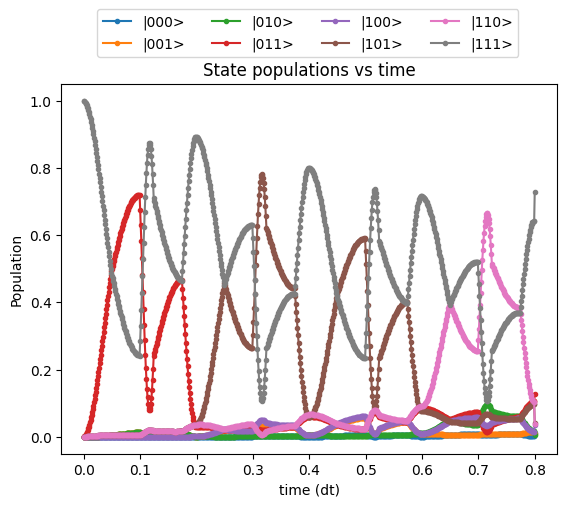

In [15]:
# plot the states to check that they make sense 
time = np.linspace(0, total_time, len(states))
# plot population
populations = []
state_labels = ["|000>", "|001>", "|010>", "|011>", "|100>", "|101>", "|110>", "|111>"]
fig, ax = plt.subplots()
for i in range(dim ** (N-2)):
    data = []
    for j in range(len(states)):
        data.append(np.real(qt.ptrace(states[j], [0,1,2])[i,i]))
    ax.plot(time, data, marker = ".", label = state_labels[i])
    populations.append(data[-1])
print(populations)
fig.legend(bbox_to_anchor=(.85, 1.05), ncol=dim ** (N-2)/2)
ax.set_title("State populations vs time")
ax.set_ylabel("Population")
ax.set_xlabel("time (dt)")